In [1]:
import torch.nn as nn
import os
import copy
import torch
import numpy as np
import wandb
from datetime import datetime

from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators

from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer
from SparseDPC.src.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator
from SparseDPC.src.utils.utils import map_to_new_fx, save_model_with_timestamp

torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1



In [3]:
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device, ) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = -0.004*x0 + 0.268*x1 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*u_0 + -0.010*u_1 + 0.396*u_0*u_1 + -0.044*x0*u_0 + 0.132*x1*u_0 + -0.151*x0*u_1 + -0.098*x1*u_1 + -0.478*sqrt(x0) + -0.331*sqrt(x1) 

dx1/dt = -0.004*x1 + 0.268*x0 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*u_0 + -0.010*u_1 + 0.396*u_0*u_1 + -0.044*x0*u_0 + 0.132*x1*u_0 + -0.151*x0*u_1 + -0.098*x1*u_1 + -0.478*sqrt(x0) + -0.331*sqrt(x1) 



In [4]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 100     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

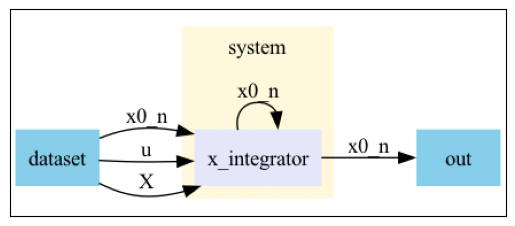

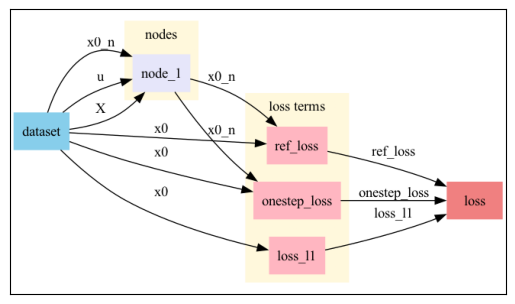

None
epoch: 0	train_loss: 0.25063	dev_loss: 0.20839	eltime:  0.84643
epoch: 100	train_loss: 0.00219	dev_loss: 0.00329	eltime:  4.27405
epoch: 200	train_loss: 0.00056	dev_loss: 0.00110	eltime:  8.28841
epoch: 300	train_loss: 0.00034	dev_loss: 0.00039	eltime:  11.93427
epoch: 400	train_loss: 0.00015	dev_loss: 0.00025	eltime:  15.42960
epoch: 500	train_loss: 0.00013	dev_loss: 0.00018	eltime:  18.68592
epoch: 600	train_loss: 0.00006	dev_loss: 0.00012	eltime:  21.79069
epoch: 700	train_loss: 0.00003	dev_loss: 0.00007	eltime:  24.87638
epoch: 800	train_loss: 0.00002	dev_loss: 0.00004	eltime:  27.83029
epoch: 900	train_loss: 0.00001	dev_loss: 0.00002	eltime:  30.74017

---------- Model 0 BEFORE pruning ----------
dx0/dt = 0.033*x0 + 0.072*x1 + 0.004*x0^2 + 0.005*x0*x1 + -0.072*x1^2 + 0.113*u_0 + 0.009*u_1 + -0.148*u_0*u_1 + -0.099*x0*u_0 + 0.015*x1*u_0 + 0.064*x0*u_1 + -0.050*x1*u_1 + -0.070*sqrt(x0) + -0.018*sqrt(x1) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change

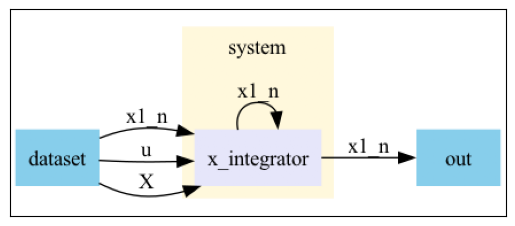

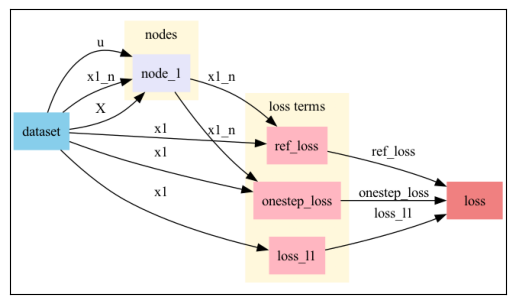

None
epoch: 0	train_loss: 1.19113	dev_loss: 1.43517	eltime:  0.97109
epoch: 100	train_loss: 0.02089	dev_loss: 0.02076	eltime:  3.16966
epoch: 200	train_loss: 0.00820	dev_loss: 0.00983	eltime:  5.52240
epoch: 300	train_loss: 0.00753	dev_loss: 0.00884	eltime:  7.82615
epoch: 400	train_loss: 0.00234	dev_loss: 0.00314	eltime:  10.01809
epoch: 500	train_loss: 0.00113	dev_loss: 0.00219	eltime:  12.32396
epoch: 600	train_loss: 0.00069	dev_loss: 0.00156	eltime:  14.52502
epoch: 700	train_loss: 0.00061	dev_loss: 0.00087	eltime:  16.84104
epoch: 800	train_loss: 0.00049	dev_loss: 0.00064	eltime:  19.04259
epoch: 900	train_loss: 0.00044	dev_loss: 0.00075	eltime:  21.32251

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.125*x1 + 0.401*x0 + -0.284*x0^2 + -0.227*x0*x1 + -0.054*x1^2 + 0.109*u_0 + 0.024*u_1 + -0.021*u_0*u_1 + -0.166*x0*u_0 + -0.051*x1*u_0 + -0.095*x0*u_1 + -0.045*x1*u_1 + -0.163*sqrt(x0) + -0.046*sqrt(x1) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No cha

In [5]:
for i in range(nx):

    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])

    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 1e-6 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=9999

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.002,
        prune_every=1000,
        warmup=300,
        patience=50,
        threshold_mult=1.07,
        )
    for _ in range(1):
        # print(f'************   training with {nsteps} steps   ************   ')

        # Regenerate data for the new `nsteps`
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps

In [6]:
for fx in fx_models:
    print(fx)

dx0/dt = -0.039*sqrt(x0) + 0.078*u_0 + -0.078*u_0*u_1 

dx1/dt = 0.080*u_0*u_1 + 0.040*sqrt(x0) + -0.040*sqrt(x1) 



In [7]:
integrator_x = FullStateEulerIntegrator(fx_models, ts)          # custom step
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")


sindy_system = System(
    [x_integrator_node],
    nsteps=nsteps
)

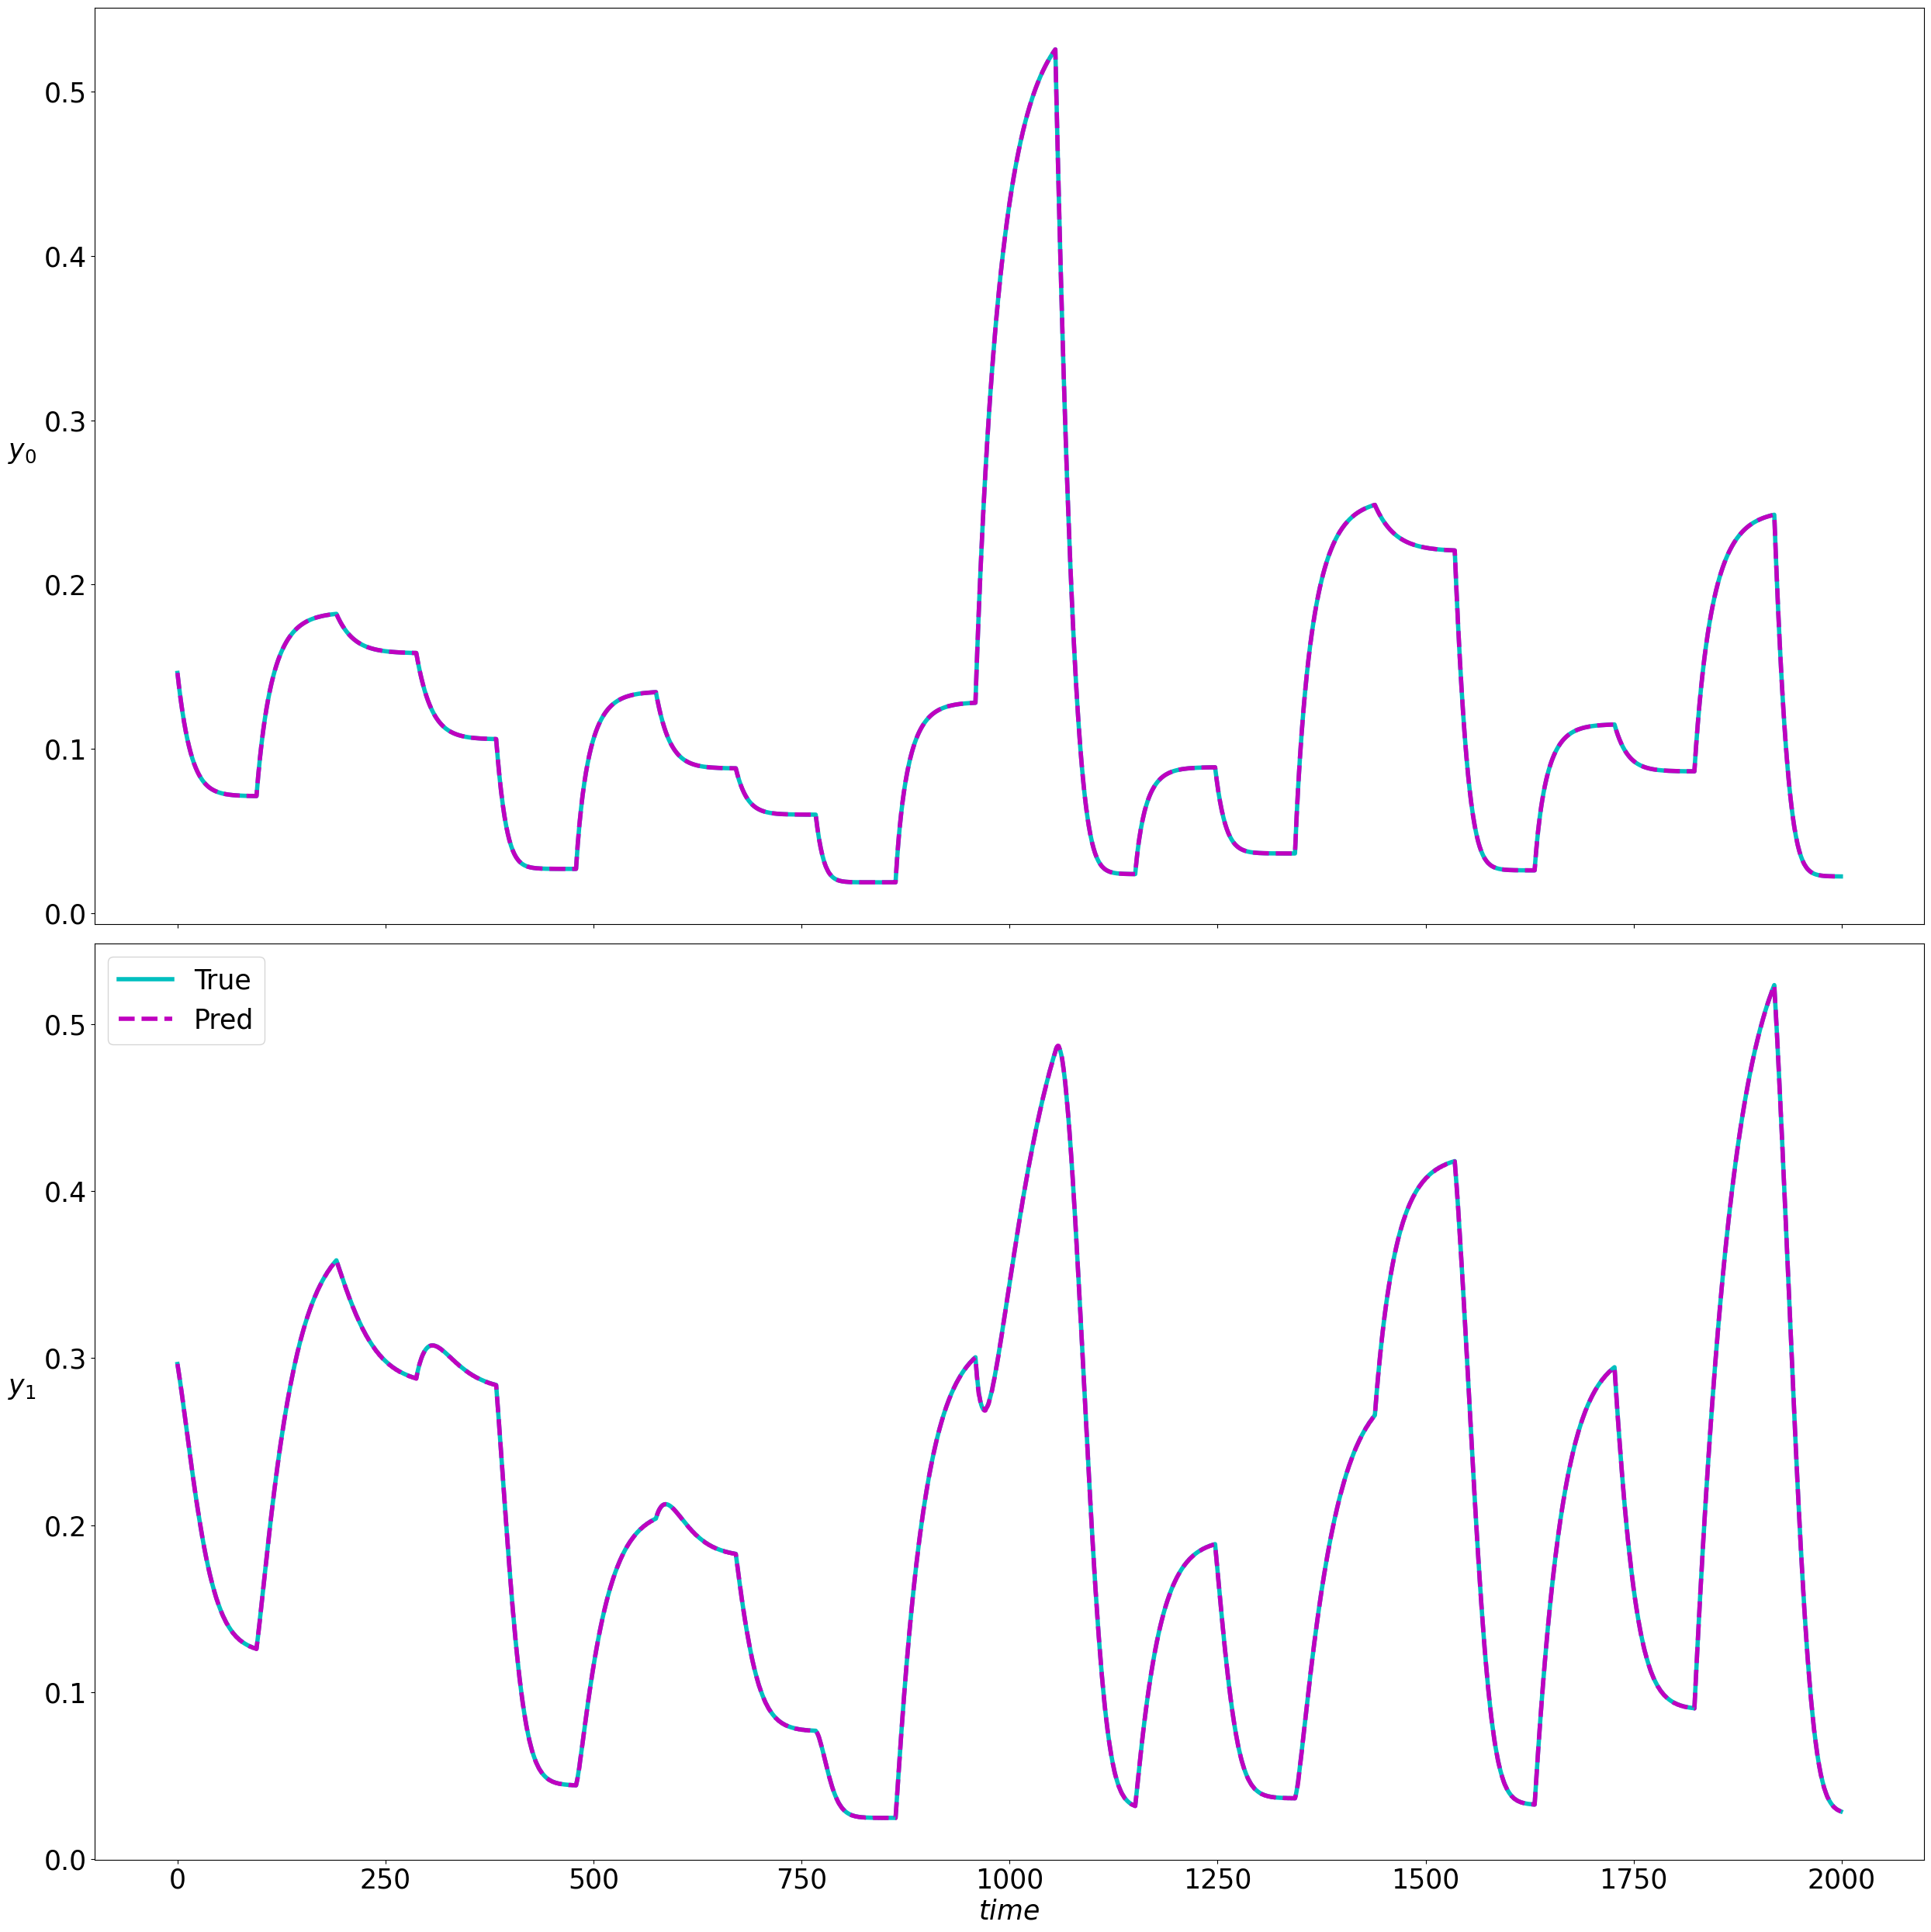

In [8]:
import matplotlib.pyplot as plt
sindy_system.nsteps = test_data['X'].shape[1]
test_output = sindy_system(test_data)

pred_traj = test_output['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

#### Policy Training

In [9]:
import importlib
import SparseDPC.src.sindy.sindy  # Import the module itself
import SparseDPC.src.sindy.fx_library
import SparseDPC.src.data.getdata
import SparseDPC.src.trainer.trainer

importlib.reload(SparseDPC.src.sindy.fx_library )  # Reload the module
importlib.reload(SparseDPC.src.sindy.sindy )
importlib.reload(SparseDPC.src.data.getdata)
importlib.reload(SparseDPC.src.trainer.trainer)
importlib.reload(SparseDPC.src.utils.utils)

from SparseDPC.src.sindy.sindy import SINDy
from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer
from SparseDPC.src.utils.utils import map_to_new_fx, save_model_with_timestamp

In [10]:
nsteps = 50  # prediction horizon
n_samples = 2500    # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )

In [11]:
from SparseDPC.src.utils.loggers import CustomLogger

In [12]:
import json

# === Setup ===
nsteps = 50
session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
session_folder = f"results/session_{session_id}"
os.makedirs(session_folder, exist_ok=True)

# === Base Configuration ===
base_config = {
    'reg_coef': 100.0,
    'l1_coef': 1e-2,
    'const_coef': 10.0,
    'lr': 5e-3,
    'epochs': 3999,
    'threshold': 0.1,
    'prune_every': 250,
    'threshold_mult': 1.1,
}
policies_seed = 5
l1_coef_list = [1e-2, 5e-3, 1e-3]
thresholds = [0.3, 0.2, 0.1, 0.05]

# === Run All Configurations ===
run_id = 0
for l1_coef in l1_coef_list:
    for threshold in thresholds:
        run_id += 1
        pol_configs = copy.deepcopy(base_config)
        pol_configs['threshold'] = threshold
        pol_configs['run_id'] = run_id

        run_name = f"TwoTank_run{run_id}_l1coef{l1_coef}_th{threshold}"
        save_dir = os.path.join(session_folder, run_name)
        os.makedirs(save_dir, exist_ok=True)

        wandb.init(
            project="sindy-TwoTank-multi-config",
            name=run_name,
            config=pol_configs,
            dir=save_dir,
            reinit=True,
        )

        # === Policy Setup ===
        policies = [
            fx_policy_library(nx=nx, nref=1, policy_name=f"u_{i}", seed=policies_seed, device=device) for i in range(nu)
        ]

        policy_node = Node(
            lambda xn, r: torch.cat([torch.clamp(fp(xn, r), umin, umax) for fp in policies], dim=-1),
            ['xn', 'r'], ['u'], name="policy_combined"
        )

        integrator_x = FullStateEulerIntegrator(fx_models, ts)
        x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")
        sindy_system = System([policy_node, x_integrator_node], nsteps=nsteps)

        x = variable('xn')
        ref = variable('r')
        regulation_loss = pol_configs['reg_coef'] * ((x == ref) ^ 2)
        regulation_loss.name = "state_loss"

        loss_l1_policies = []
        for idx, fp in enumerate(policies):
            l1_raw = variable([x], lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1), display_name=f"l1_policy{idx}")
            l1_pen = l1_coef * (l1_raw == 0)
            l1_pen.name = f"loss_l1_policy_{idx}"
            loss_l1_policies.append(l1_pen)

        c = pol_configs['const_coef']
        state_lower = c * (x > xmin); state_lower.name = "x_min"
        state_upper = c * (x < xmax); state_upper.name = "x_max"
        term_lower = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
        term_upper = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

        objectives = [regulation_loss, *loss_l1_policies]
        constraints = [state_lower, state_upper, term_lower, term_upper]
        loss = PenaltyLoss(objectives, constraints)
        problem = Problem([sindy_system], loss)

        logger = CustomLogger(
            args=None,
            save_dir=save_dir,
            verbosity=10,
            stdout=['train_loss', 'dev_loss'],
            fx_policies=policies,
            pol_configs=pol_configs
        )

        trainer_policy = SparseTrainer(
            problem=problem,
            fx_models=policies,
            lr=pol_configs['lr'],
            train_data=train_loader,
            dev_data=dev_loader,
            optimizers=[torch.optim.AdamW(fp.parameters(), lr=pol_configs['lr']) for fp in policies],
            epochs=pol_configs['epochs'],
            train_metric='train_loss',
            eval_metric='dev_loss',
            logger=logger,
            device=device,
            threshold=pol_configs['threshold'],
            prune_every=pol_configs['prune_every'],
            threshold_mult=pol_configs['threshold_mult']
        )

        best_state = trainer_policy.train()
        # === Save final coefficients
        for i, fp in enumerate(policies):
            coef = fp.coef.detach().cpu().numpy()
            np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
            wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})

        # === Save mapped models
        models_dir = os.path.join(save_dir, "saved_models")
        os.makedirs(models_dir, exist_ok=True)

        # Create corresponding master policies and save the mapped models
        for i in range(nu):
            policy_name = f"u_{i}"

            # Create a base fx policy (untrained) to map to full library
            policy_base = fx_policy_library(
                nx=nx, nref=1, policy_name=policy_name, seed=policies_seed, device=device
            )

            # Map trained policy to full library structure
            policy_mapped = map_to_new_fx(policies[i], policy_base)

            # Save the mapped model
            save_model_with_timestamp(policy_mapped, f"trained_policy_{i}", models_dir)

        with open(os.path.join(save_dir, "run_config.json"), "w") as f:
            json.dump(pol_configs, f, indent=4)

        wandb.finish()

# === Save session metadata ===
with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
    f.write(f"Session ID: {session_id}\n")
    f.write(f"Started at: {datetime.now()}\n")
    f.write(f"Total runs: {run_id}\n")
    f.write(f"L1 Coef List: {l1_coef_list}\n")
    f.write(f"Thresholds: {thresholds}\n")


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: alirezad126 (alirezad126-johns-hopkins-university). Use `wandb login --relogin` to force relogin


None
epoch: 0	train_loss: 7.30296	dev_loss: 8.27828	eltime:  2.22502
epoch: 10	train_loss: 3.91052	dev_loss: 4.81194	eltime:  25.94253
epoch: 20	train_loss: 3.75406	dev_loss: 4.62465	eltime:  49.42336
epoch: 30	train_loss: 3.67824	dev_loss: 4.53831	eltime:  73.74596
epoch: 40	train_loss: 3.63534	dev_loss: 4.48956	eltime:  98.06076
epoch: 50	train_loss: 3.60733	dev_loss: 4.45694	eltime:  122.27257
epoch: 60	train_loss: 3.58715	dev_loss: 4.43390	eltime:  146.77226
epoch: 70	train_loss: 3.57116	dev_loss: 4.41623	eltime:  171.83437
epoch: 80	train_loss: 3.55885	dev_loss: 4.40284	eltime:  196.29137
epoch: 90	train_loss: 3.54808	dev_loss: 4.39155	eltime:  220.82892
epoch: 100	train_loss: 3.53922	dev_loss: 4.38223	eltime:  245.56086
epoch: 110	train_loss: 3.53319	dev_loss: 4.37597	eltime:  270.15795
epoch: 120	train_loss: 3.52750	dev_loss: 4.37043	eltime:  294.65482
epoch: 130	train_loss: 3.52246	dev_loss: 4.36505	eltime:  319.17664
epoch: 140	train_loss: 3.51779	dev_loss: 4.35986	eltime:  34

active_terms_policy_0,█▄▃▂▂▂▂▂▂▂▂▂▂▂▁▁
active_terms_policy_1,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dev_loss,▂▁▁▁▁▁▁▁▁▁▁▁▁▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂███
epoch,▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
final_active_terms_policy_0,▁
final_active_terms_policy_1,▁
train_loss,▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂█████
active_terms_policy_0,2
active_terms_policy_1,2
dev_loss,5.19597
epoch,3998


None
epoch: 0	train_loss: 7.30296	dev_loss: 8.27828	eltime:  2.63061
epoch: 10	train_loss: 3.91052	dev_loss: 4.81194	eltime:  29.56513
epoch: 20	train_loss: 3.75406	dev_loss: 4.62465	eltime:  56.36313
epoch: 30	train_loss: 3.67824	dev_loss: 4.53831	eltime:  83.38824
epoch: 40	train_loss: 3.63534	dev_loss: 4.48956	eltime:  110.22486
epoch: 50	train_loss: 3.60733	dev_loss: 4.45694	eltime:  137.50601
epoch: 60	train_loss: 3.58715	dev_loss: 4.43390	eltime:  164.08494
epoch: 70	train_loss: 3.57116	dev_loss: 4.41623	eltime:  191.35746
epoch: 80	train_loss: 3.55885	dev_loss: 4.40284	eltime:  218.27927
epoch: 90	train_loss: 3.54808	dev_loss: 4.39155	eltime:  245.10325
epoch: 100	train_loss: 3.53922	dev_loss: 4.38223	eltime:  272.00415
epoch: 110	train_loss: 3.53319	dev_loss: 4.37597	eltime:  298.86471
epoch: 120	train_loss: 3.52750	dev_loss: 4.37043	eltime:  325.89744
epoch: 130	train_loss: 3.52246	dev_loss: 4.36505	eltime:  352.72258
epoch: 140	train_loss: 3.51779	dev_loss: 4.35986	eltime:  3

wandb: ERROR Control-C detected -- Run data was not synced

KeyboardInterrupt



In [ ]:
pol_configs={'reg_coef': 100.0,
             'l1_coef': 1e-2,
             'const_coef': 20.0,
             'lr': 1e-2,
             'epochs': 1500,
             'threshold': 0.3,
             'prune_every': 150,
             'threshold_mult': 1.1,
             }

fx_policies = [fx_policy_library(nx=2, nref=1, policy_name= "p", seed=policies_seed, device=device),
               fx_policy_library(nx=2, nref=1, policy_name= "v", seed=policies_seed, device=device)]

# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

# ------------------------------------------------------------------ #
# build integrator node and system
# ------------------------------------------------------------------ #

integrator_x = FullStateEulerIntegrator(fx_models, ts)
x_integrator_node= Node(integrator_x,['xn', 'u'], ['xn'], name=f"x_integrator")
sindy_system = System(
    [policy_node, x_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x   = variable('xn')
ref = variable('r')

regulation_loss      = pol_configs["reg_coef"] * ((x == ref) ^ 2); regulation_loss.name = "state_loss"

#   L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = pol_configs["l1_coef"] * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
c = pol_configs["const_coef"]
state_lower  = c * (x > xmin);           state_lower.name  = "x_min"
state_upper  = c * (x < xmax);           state_upper.name  = "x_max"
term_lower   = c * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = c * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem  = Problem([sindy_system], loss)
problem.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = pol_configs['lr']
optimizers = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies]

trainer_policy = SparseTrainer(
    problem     = problem,
    fx_models   = fx_policies,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers,
    epochs      = pol_configs['epochs'],
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=10,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = pol_configs['threshold'],
    prune_every = pol_configs["prune_every"],
    threshold_mult=pol_configs["threshold_mult"]
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy.train()
trainer_policy.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")


In [ ]:
for fp in policies:
    print(fp)

In [ ]:
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

In [ ]:
# white-box
# ODE model with no-plant model mismatch
two_tank = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)
# integrate continuous time ODE
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

import copy
gt_sindy_policy = copy.deepcopy(System([policy_node,
                       gt_integrator_node]))
gt_sindy_policy.show()

In [ ]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 1500
torch.manual_seed(63)
seed = 52
rng = np.random.default_rng(seed)
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=7, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {'xn': x_sample,
        'x0_n': x_sample[:,:,0:1],
        'x1_n': x_sample[:,:,1:2],
        'r': torch_ref}

gt_sindy_policy.nsteps = nsteps
# perform closed-loop simulation
trajectories = gt_sindy_policy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().cpu().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().cpu().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

### Sparse Policy with Whitebox model

In [ ]:
nsteps=50
fx_policies_wb = [fx_policy_library(nx=2, nref=1, policy_name= "p", seed=policies_seed, device=device),
               fx_policy_library(nx=2, nref=1, policy_name= "v", seed=policies_seed, device=device)]

for fp in fx_policies_wb:
    print(fp)

In [ ]:
# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node_wb = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies_wb],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)


sindy_system_wb = System(
    [policy_node_wb, gt_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x_wb   = variable('xn')
ref_wb = variable('r')

regulation_loss_wb      = 100.0 * ((x == ref) ^ 2); regulation_loss_wb.name = "state_loss"

#  L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies_wb):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = 0.001 * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = 20.0 * (x > xmin);           state_lower.name  = "x_min"
state_upper  = 20.0 * (x < xmax);           state_upper.name  = "x_max"
term_lower   = 20.0 * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = 20.0 * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem_wb  = Problem([sindy_system_wb], loss)
problem_wb.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = 0.008
optimizers_wb = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies_wb]

trainer_policy_wb = SparseTrainer(
    problem     = problem_wb,
    fx_models   = fx_policies_wb,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers_wb,
    epochs      = 1200,
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=10,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = 0.20,
    prune_every = 100,
    threshold_mult=1.11
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy_wb.train()
trainer_policy_wb.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies_wb):
    print(f"Policy {i}:\n{fp}\n")


In [ ]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 1500
torch.manual_seed(63)
seed = 84
rng = np.random.default_rng(seed)
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {'xn': x_sample,
        'x0_n': x_sample[:,:,0:1],
        'x1_n': x_sample[:,:,1:2],
        'r': torch_ref}

sindy_system_wb.nsteps = nsteps
# perform closed-loop simulation
trajectories = sindy_system_wb(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

In [ ]:
for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")

In [ ]:
for i, fp in enumerate(fx_policies_wb):
    print(f"Policy {i}:\n{fp}\n")